In [1]:
# imports

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import random_split
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

from typing import Union, Dict, List
from scipy.ndimage import label

from torch.utils.data import TensorDataset, DataLoader
import fitsio
import matplotlib.pyplot as plt

In [2]:
def save_model_checkpoint(
    filepath: str,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer = None,
    scheduler = None,
    epoch: int = 0,
    val_loss: float = float("inf"),
    config: dict = None
):
    """
    Saves a comprehensive PyTorch model checkpoint.
    """
    checkpoint = {
        "epoch": epoch,
        "val_loss": val_loss,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "config": config or {}
    }
    torch.save(checkpoint, filepath)
    print(f"--> Saved checkpoint to '{filepath}' (Epoch {epoch+1}, Val Loss: {val_loss:.4f})")


def load_model_checkpoint(
    filepath: str,
    device: torch.device,
    model_class=None,
):
    """
    Loads a saved checkpoint and returns the model, optimizer/scheduler states, and metadata.
    """
    checkpoint = torch.load(filepath, map_location=device)
    config = checkpoint["config"]

    # Reconstruct model architecture using stored configuration
    model = model_class(
        in_channels=config.get("in_channels", 2),
        num_species=config.get("num_species", 1)
    ).to(device)

    # Load weights
    model.load_state_dict(checkpoint["model_state_dict"])
    
    print(f"--> Loaded checkpoint '{filepath}' (Trained for {checkpoint['epoch']+1} epochs, Val Loss: {checkpoint['val_loss']:.4f})")
    return model, checkpoint


In [3]:
#list of all metals 

# metal_list = [
#     "MgI(2853)", "MgII(2804)", "MgII(2796)",
#     "FeII(2600)", "FeII(2587)", "MnII(2577)",
#     "FeII(2383)", "FeII(2374)", "FeII(2344)",
#     "AlIII(1863)", "AlIII(1855)", "AlII(1671)",
#     "FeII(1608)", "CIV(1551)", "CIV(1548)",
#     "SiII(1527)", "SiIV(1403)", "SiIV(1394)",
#     "CII(1335)", "SiII(1304)", "OI(1302)",
#     "SiII(1260)", "NV(1243)", "NV(1239)",
#     "SiIII(1207)", "NI(1200)", "SiII(1193)", "SiII(1190)",
#     "OI(1039)", "OVI(1038)", "OVI(1032)",
#     "LYB", "CIII(977)", "OI(989)", "SiII(990)",
#     "LY3", "LY4", "LY5",
# ]
# strength_list = [
#     "1e-4", "5e-4", "9e-4",          # MgI MgII(2804) MgII(2796)
#     "1e-4", "1e-4", "1e-4",          # FeII(2600) FeII(2587) MnII(2577)
#     "1e-4", "1e-4", "1e-4",          # FeII(2383) FeII(2374) FeII(2344)
#     "1e-4", "1e-4", "1e-4",          # AlIII(1863) AlIII(1855) AlII(1671)
#     "1e-4", "5.435e-4", "1.487e-3",  # FeII(1608) CIV(1551) CIV(1548)
#     "1e-4", "5e-4", "9e-4",          # SiII(1527) SiIV(1403) SiIV(1394)
#     "1e-4", "1e-4", "1e-4",          # CII(1335) SiII(1304) OI(1302)
#     "4.2504e-4", "5e-4", "5e-4",     # SiII(1260)* NV(1243) NV(1239)
#     "9.4595e-4", "1e-3", "6.354e-4", "4.496e-4",  # SiIII(1207)* NI(1200) SiII(1193)* SiII(1190)*
#     "1e-3", "3.382e-3", "5.358e-3",  # OI(1039) OVI(1038) OVI(1032)
#     "0.1901", "5e-3", "1e-3", "1e-3",# LYB CIII(977) OI(989) SiII(990)
#     "0.0697", "0.0335", "0.0187",    # LY3 LY4 LY5
# ]


# # Expected format: 
# METAL_LINES_LIST = {
#     "SiII_1190": 1190.4158,
#     "SiII_1193": 1193.2897,
#     "SiIII_1207": 1206.500,
#     "SiII_1260": 1206.500,
#     "CIV_1548": 1548.2049,
#     "CIV_1550": 1550.77845,
#     'MgI(2853)': 2852.96,
# }

### Check transmission file from P1D code

Wavelength shape: (31001,)
Single flux shape: (31001,)


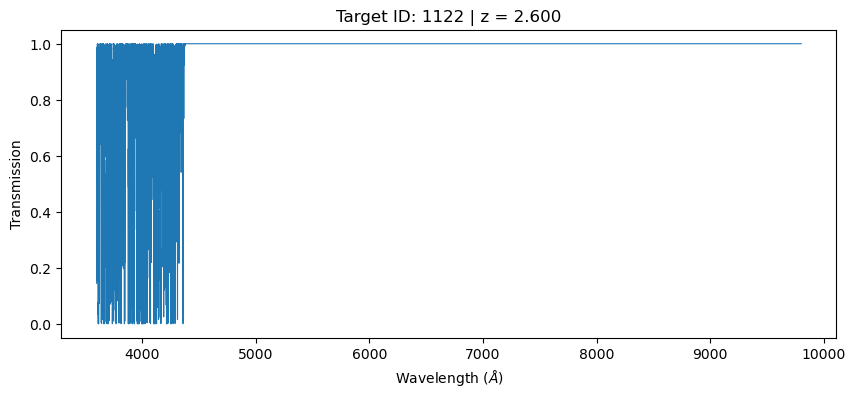

In [4]:
# load transmission file (preprocessed)
p1d_file = '/global/cfs/cdirs/desicollab/users/mherbold/p1d_mocks/DR1/QQ_output_test/transmission-16-1_2.fits'

# Read arrays
meta = fitsio.read(p1d_file, ext="METADATA")
wave = fitsio.read(p1d_file, ext="WAVELENGTH")
fluxes = fitsio.read(p1d_file, ext="TRANSMISSION")

# Pick single spectrum index
i = 100

# Extract and squeeze shape
single_flux = fluxes[i].squeeze()
target_id = meta["MOCKID"][i]
z = meta["Z"][i]

# Check shapes directly
print(f"Wavelength shape: {wave.shape}")        # Output: (31001,)
print(f"Single flux shape: {single_flux.shape}")  # Output: (31001,)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(wave, single_flux, lw=0.8)
plt.xlabel(r"Wavelength ($\AA$)")
plt.ylabel("Transmission")
plt.title(f"Target ID: {target_id} | z = {z:.3f}")
# plt.xlim(3000,5000)
plt.show()

### Generate training samples

In [5]:
def rebin_dataset_to_log_lambda(wave_grid: np.ndarray, fluxes: np.ndarray, num_log_pixels: int = None):
    """
    Interpolates a batch of flux spectra from a linear wavelength grid 
    to a strictly uniform log-wavelength grid (constant delta ln(wave)).
    """
    # Define uniform log-wavelength bounds
    log_wave_min = np.log(wave_grid[0])
    log_wave_max = np.log(wave_grid[-1])
    
    if num_log_pixels is None:
        num_log_pixels = len(wave_grid)
        
    log_wave_grid = np.linspace(log_wave_min, log_wave_max, num_log_pixels)
    linear_wave_from_log = np.exp(log_wave_grid)
    
    # Re-interpolate all spectra onto the new uniform log wavelength grid
    N_specs = fluxes.shape[0]
    fluxes_log = np.zeros((N_specs, num_log_pixels), dtype=np.float32)
    
    for idx in range(N_specs):
        fluxes_log[idx] = np.interp(linear_wave_from_log, wave_grid, fluxes[idx])
        
    return log_wave_grid, fluxes_log

In [6]:
def generate_multimetal_dataset(
    lya_flux_samples: np.ndarray,
    log_wave_grid: np.ndarray,
    metal_dict: dict,
    lya_wave: float = 1215.67,
    num_samples: int = 5000,
    max_metals_per_spectrum: int = 1,
    snr: float = 30.0,                 # noise injected into INPUT flux; None = noiseless input
    target_snr: float = 30.0,          # SNR used for SNR-based detection thresholding
    detect_sigma: float = 3.0,         # significance threshold
    tau_min_fraction: float = 0.0,     # per-species or global fractional floor (relative to tau_lya)
    tau_min_thresh = None,             # explicit threshold override
    zero_metal_prob: float = 0.25,
    a_min = 0.2,
    a_max = 1.0,
) -> TensorDataset:
    """
    Generates synthetic multi-metal spectrum dataset with flexible per-species amplitudes 
    and relative optical depth masks that do not collapse at low amplitudes.
    """   
    n_input, n_pixels = lya_flux_samples.shape
    num_species = len(metal_dict)
    species_keys = list(metal_dict.keys())
    d_log_wave = log_wave_grid[1] - log_wave_grid[0]
    
    pixel_shifts = {
        key: int(np.round(np.log(w / lya_wave) / d_log_wave))
        for key, w in metal_dict.items()
    }

    X_data = np.zeros((num_samples, 1 + num_species, n_pixels), dtype=np.float32)
    Y_mask = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)
    # Initialize Y_amp with a sentinel (-10.0) so unmasked background doesn't default to A=1.0 (log10=0)
    Y_amp  = np.full((num_samples, num_species, n_pixels), -10.0, dtype=np.float32)

    tau_lya_pool = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

    for i in range(num_samples):
        rand_idx = np.random.randint(0, n_input)
        tau_lya = tau_lya_pool[rand_idx]
        tau_total = np.copy(tau_lya)
        
        inject_metal = (np.random.rand() > zero_metal_prob)

        if inject_metal:
            n_active = np.random.randint(1, max_metals_per_spectrum + 1)
            active_species = np.random.choice(species_keys, size=n_active, replace=False)

            for species in active_species:
                s_idx = species_keys.index(species)
                shift = pixel_shifts[species]
                
                # --- Resolve per-species a_min and a_max ---
                if isinstance(a_min, dict):
                    sp_a_min = a_min.get(species, 0.2)
                elif isinstance(a_min, (list, tuple)):
                    sp_a_min = a_min[s_idx]
                else:
                    sp_a_min = float(a_min)

                if isinstance(a_max, dict):
                    sp_a_max = a_max.get(species, 1.0)
                elif isinstance(a_max, (list, tuple)):
                    sp_a_max = a_max[s_idx]
                else:
                    sp_a_max = float(a_max)

                # --- Resolve per-species tau_min_fraction ---
                if isinstance(tau_min_fraction, dict):
                    sp_tau_frac = tau_min_fraction.get(species, 0.05)
                elif isinstance(tau_min_fraction, (list, tuple)):
                    sp_tau_frac = tau_min_fraction[s_idx]
                else:
                    sp_tau_frac = float(tau_min_fraction)

                log_a_min, log_a_max = np.log10(sp_a_min), np.log10(sp_a_max)
                log10_A = np.random.uniform(log_a_min, log_a_max) if log_a_min != log_a_max else log_a_min
                A = 10.0 ** log10_A

                tau_metal = np.roll(tau_lya, shift)
                if shift > 0:
                    tau_metal[:shift] = 0.0
                elif shift < 0:
                    tau_metal[shift:] = 0.0
                
                tau_metal_effective = A * tau_metal
                tau_total += tau_metal_effective
                
                # --- Resolve optical depth mask threshold ---
                if tau_min_thresh is not None:
                    if isinstance(tau_min_thresh, dict):
                        sp_tau_thresh = tau_min_thresh.get(species, 0.05)
                    elif isinstance(tau_min_thresh, (list, tuple)):
                        sp_tau_thresh = tau_min_thresh[s_idx]
                    else:
                        sp_tau_thresh = float(tau_min_thresh)
                    metal_active_mask = (tau_metal_effective >= sp_tau_thresh)
                else:
                    # Scale threshold with relative structural tau_lya profile
                    # or scale SNR floor relative to metal amplitude A
                    metal_active_mask = (tau_metal >= sp_tau_frac)

                Y_mask[i, s_idx, :] = metal_active_mask.astype(np.float32)
                Y_amp[i, s_idx, :]  = log10_A

        # Flux conversion & noise injection
        flux_true = np.exp(-tau_total)
        if snr is None or snr >= 1e5:
            flux_obs = flux_true
        else:
            noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
            flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
        tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

        X_data[i, 0, :] = tau_obs
        for s_idx, species in enumerate(species_keys):
            shift = pixel_shifts[species]
            X_data[i, 1 + s_idx, :] = np.roll(tau_obs, shift)

    return TensorDataset(
        torch.from_numpy(X_data),
        torch.from_numpy(Y_mask),
        torch.from_numpy(Y_amp)
    )

In [7]:
# def generate_multimetal_dataset(
#     lya_flux_samples: np.ndarray,
#     log_wave_grid: np.ndarray,
#     metal_dict: dict,
#     lya_wave: float = 1215.67,
#     num_samples: int = 5000,
#     max_metals_per_spectrum: int = 1,
#     snr: float = 30.0,                 # noise injected into the INPUT flux; None = noiseless input
#     target_snr: float = 30.0,          # SNR used ONLY to define what counts as "detectable" for the mask
#     detect_sigma: float = 3.0,         # significance threshold (e.g. 3-sigma) for a pixel to count as active
#     tau_min_fraction: float = 0.0,     # optional extra fractional floor; set 0 to disable
#     tau_min_thresh=None,               # explicit override, same as before
#     zero_metal_prob: float = 0.25,
#     a_min=0.2,
#     a_max=1.0,
# ) -> TensorDataset:
#     """
#     Generates a synthetic multi-metal spectrum dataset with flexible per-species amplitudes 
#     and automatically scaled optical depth target masks.
#     """   
#     n_input, n_pixels = lya_flux_samples.shape
#     num_species = len(metal_dict)
#     species_keys = list(metal_dict.keys())
#     d_log_wave = log_wave_grid[1] - log_wave_grid[0]
    
#     pixel_shifts = {
#         key: int(np.round(np.log(w / lya_wave) / d_log_wave))
#         for key, w in metal_dict.items()
#     }

#     X_data = np.zeros((num_samples, 1 + num_species, n_pixels), dtype=np.float32)
#     Y_mask = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)
#     Y_amp  = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)

#     tau_lya_pool = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

#     for i in range(num_samples):
#         rand_idx = np.random.randint(0, n_input)
#         tau_lya = tau_lya_pool[rand_idx]
#         tau_total = np.copy(tau_lya)
        
#         # Decide whether to inject metals into this sample
#         inject_metal = (np.random.rand() > zero_metal_prob)

#         if inject_metal:
#             n_active = np.random.randint(1, max_metals_per_spectrum + 1)
#             active_species = np.random.choice(species_keys, size=n_active, replace=False)

#             sigma_tau_floor = detect_sigma / target_snr
            
#             for species in active_species:
#                 s_idx = species_keys.index(species)
#                 shift = pixel_shifts[species]
                
#                 # --- Resolve per-species a_min and a_max ---
#                 if isinstance(a_min, dict):
#                     sp_a_min = a_min.get(species, 0.2)
#                 elif isinstance(a_min, (list, tuple)):
#                     sp_a_min = a_min[s_idx]
#                 else:
#                     sp_a_min = float(a_min)

#                 if isinstance(a_max, dict):
#                     sp_a_max = a_max.get(species, 1.0)
#                 elif isinstance(a_max, (list, tuple)):
#                     sp_a_max = a_max[s_idx]
#                 else:
#                     sp_a_max = float(a_max)

#                 # Sample amplitude A for this species
#                 # A = np.random.uniform(sp_a_min, sp_a_max) if sp_a_min != sp_a_max else sp_a_min
#                 # log10_A = np.log10(A)
#                 log_a_min, log_a_max = np.log10(sp_a_min), np.log10(sp_a_max)
#                 log10_A = np.random.uniform(log_a_min, log_a_max)
#                 A = 10.0 ** log10_A

#                 tau_metal = np.roll(tau_lya, shift)
#                 if shift > 0:
#                     tau_metal[:shift] = 0.0
#                 elif shift < 0:
#                     tau_metal[shift:] = 0.0
                
#                 tau_metal_effective = A * tau_metal
#                 tau_total += tau_metal_effective
        
#                 # --- Resolve optical depth mask threshold ---
#                 if tau_min_thresh is not None:
#                     # User-provided explicit threshold override
#                     if isinstance(tau_min_thresh, dict):
#                         sp_tau_thresh = tau_min_thresh.get(species, 0.05)
#                     elif isinstance(tau_min_thresh, (list, tuple)):
#                         sp_tau_thresh = tau_min_thresh[s_idx]
#                     else:
#                         sp_tau_thresh = float(tau_min_thresh)
#                 else:
#                     # Detectable = perturbation exceeds the noise floor, with an optional
#                     # small fractional buffer. This does NOT cancel with A.
#                     sp_tau_thresh = max(sigma_tau_floor, A * tau_min_fraction)
        
#                 metal_active_mask = (tau_metal_effective >= sp_tau_thresh)
#                 Y_mask[i, s_idx, :] = metal_active_mask.astype(np.float32)
#                 Y_amp[i, s_idx, :]  = log10_A

#         # Flux conversion & noise injection
#         flux_true = np.exp(-tau_total)
#         if snr is None or snr >= 1e5:
#             flux_obs = flux_true
#         else:
#             noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
#             flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
#         tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

#         X_data[i, 0, :] = tau_obs
#         for s_idx, species in enumerate(species_keys):
#             shift = pixel_shifts[species]
#             X_data[i, 1 + s_idx, :] = np.roll(tau_obs, shift)

#     return TensorDataset(
#         torch.from_numpy(X_data),
#         torch.from_numpy(Y_mask),
#         torch.from_numpy(Y_amp)
#     )

# # def generate_multimetal_dataset(
# #     lya_flux_samples: np.ndarray,
# #     log_wave_grid: np.ndarray,
# #     metal_dict: dict,
# #     lya_wave: float = 1215.67,
# #     num_samples: int = 5000,           # Increased sample count
# #     max_metals_per_spectrum: int = 1,
# #     snr: float = 30.0,
# #     tau_min_thresh: float = 0.05,
# #     zero_metal_prob: float = 0.25,      # 25% pure LyA forest spectra (no metals)
# #     a_min: float = 0.2,
# #     a_max: float = 1.0,
# # ) -> TensorDataset:
    
# #     n_input, n_pixels = lya_flux_samples.shape
# #     num_species = len(metal_dict)
# #     species_keys = list(metal_dict.keys())
# #     d_log_wave = log_wave_grid[1] - log_wave_grid[0]
    
# #     pixel_shifts = {
# #         key: int(np.round(np.log(w / lya_wave) / d_log_wave))
# #         for key, w in metal_dict.items()
# #     }

# #     X_data = np.zeros((num_samples, 1 + num_species, n_pixels), dtype=np.float32)
# #     Y_mask = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)
# #     Y_amp  = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)

# #     tau_lya_pool = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

# #     for i in range(num_samples):
# #         rand_idx = np.random.randint(0, n_input)
# #         tau_lya = tau_lya_pool[rand_idx]
# #         tau_total = np.copy(tau_lya)
        
# #         # Decide whether to inject metals into this sample
# #         inject_metal = (np.random.rand() > zero_metal_prob)

# #         if inject_metal:
# #             n_active = np.random.randint(1, max_metals_per_spectrum + 1)
# #             active_species = np.random.choice(species_keys, size=n_active, replace=False)

# #             for species in active_species:
# #                 s_idx = species_keys.index(species)
# #                 shift = pixel_shifts[species]
                
# #                 A = np.random.uniform(a_min, a_max)
# #                 log10_A = np.log10(A)
                
# #                 tau_metal = np.roll(tau_lya, shift)
# #                 if shift > 0:
# #                     tau_metal[:shift] = 0.0
# #                 elif shift < 0:
# #                     tau_metal[shift:] = 0.0
                    
# #                 tau_metal_effective = A * tau_metal
# #                 tau_total += tau_metal_effective
                
# #                 metal_active_mask = (tau_metal_effective >= tau_min_thresh)
# #                 Y_mask[i, s_idx, :] = metal_active_mask.astype(np.float32)
# #                 Y_amp[i, s_idx, :]  = log10_A

# #         # Flux conversion & noise injection
# #         flux_true = np.exp(-tau_total)
# #         if snr is None or snr >= 1e5:
# #             flux_obs = flux_true
# #         else:
# #             noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
# #             flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
# #         tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

# #         X_data[i, 0, :] = tau_obs
# #         for s_idx, species in enumerate(species_keys):
# #             shift = pixel_shifts[species]
# #             X_data[i, 1 + s_idx, :] = np.roll(tau_obs, shift)

# #     return TensorDataset(
# #         torch.from_numpy(X_data),
# #         torch.from_numpy(Y_mask),
# #         torch.from_numpy(Y_amp)
# #     )


# # def generate_multimetal_dataset(
# #     lya_flux_samples: np.ndarray,
# #     log_wave_grid: np.ndarray,
# #     metal_dict: dict,
# #     lya_wave: float = 1215.67,
# #     num_samples: int = 5000,           # Increased sample count
# #     max_metals_per_spectrum: int = 1,
# #     snr: float = 30.0,
# #     tau_min_thresh: float = 0.05,
# #     zero_metal_prob: float = 0.25,      # 25% pure LyA forest spectra (no metals)
# #     a_min: float = 0.2,
# #     a_max: float = 1.0,
# # ) -> TensorDataset:
    
# #     n_input, n_pixels = lya_flux_samples.shape
# #     num_species = len(metal_dict)
# #     species_keys = list(metal_dict.keys())
# #     d_log_wave = log_wave_grid[1] - log_wave_grid[0]
    
# #     pixel_shifts = {
# #         key: int(np.round(np.log(w / lya_wave) / d_log_wave))
# #         for key, w in metal_dict.items()
# #     }

# #     X_data = np.zeros((num_samples, 1 + num_species, n_pixels), dtype=np.float32)
# #     Y_mask = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)
# #     Y_amp  = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)

# #     tau_lya_pool = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

# #     for i in range(num_samples):
# #         rand_idx = np.random.randint(0, n_input)
# #         tau_lya = tau_lya_pool[rand_idx]
# #         tau_total = np.copy(tau_lya)
        
# #         # Decide whether to inject metals into this sample
# #         inject_metal = (np.random.rand() > zero_metal_prob)

# #         if inject_metal:
# #             n_active = np.random.randint(1, max_metals_per_spectrum + 1)
# #             active_species = np.random.choice(species_keys, size=n_active, replace=False)

# #             for species in active_species:
# #                 s_idx = species_keys.index(species)
# #                 shift = pixel_shifts[species]
                
# #                 A = np.random.uniform(a_min, a_max)
# #                 log10_A = np.log10(A)
                
# #                 tau_metal = np.roll(tau_lya, shift)
# #                 if shift > 0:
# #                     tau_metal[:shift] = 0.0
# #                 elif shift < 0:
# #                     tau_metal[shift:] = 0.0
                    
# #                 tau_metal_effective = A * tau_metal
# #                 tau_total += tau_metal_effective
                
# #                 metal_active_mask = (tau_metal_effective >= tau_min_thresh)
# #                 Y_mask[i, s_idx, :] = metal_active_mask.astype(np.float32)
# #                 Y_amp[i, s_idx, :]  = log10_A

# #         # Flux conversion & noise injection
# #         flux_true = np.exp(-tau_total)
# #         if snr is None or snr >= 1e5:
# #             flux_obs = flux_true
# #         else:
# #             noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
# #             flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
# #         tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

# #         X_data[i, 0, :] = tau_obs
# #         for s_idx, species in enumerate(species_keys):
# #             shift = pixel_shifts[species]
# #             X_data[i, 1 + s_idx, :] = np.roll(tau_obs, shift)

# #     return TensorDataset(
# #         torch.from_numpy(X_data),
# #         torch.from_numpy(Y_mask),
# #         torch.from_numpy(Y_amp)
# #     )

In [8]:
# # 1. Resample wavelength AND fluxes to uniform log space
# log_wave, fluxes_log = rebin_dataset_to_log_lambda(wave, fluxes)

# # 2. Build multi-metal dataset
# dataset = generate_multimetal_dataset(
#     lya_flux_samples=fluxes_log,
#     log_wave_grid=log_wave,
#     # metal_dict={"SiII_1260": 1260.42, 'MgI_2853': 2852.96, "CIV_1550": 1550.77845},
#     metal_dict={'MgI_2853': 2852.96},
#     num_samples=5000,
#     max_metals_per_spectrum=1,
#     tau_min_thresh = 0.05,
#     zero_metal_prob = 0.25, # 25% pure LyA forest spectra (no metals)
#     snr=None,
#     a_min = 0.01, 
#     a_max = 0.01,    
#     )

# # 3. Create DataLoader (Yields: X, y_mask, y_amp)
# train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# # Test shape of single batch
# for X_batch, y_mask_batch, y_amp_batch in train_loader:
#     print(f"X batch shape:      {X_batch.shape}")      # (32, 2, 31001)
#     print(f"Mask batch shape:   {y_mask_batch.shape}") # (32, 1, 31001)
#     print(f"Amp batch shape:    {y_amp_batch.shape}")  # (32, 1, 31001)
#     break

In [9]:
# # 1. Resample wavelength AND fluxes to uniform log space
# log_wave, fluxes_log = rebin_dataset_to_log_lambda(wave, fluxes)

# n_total = len(fluxes_log)
# train_end = int(0.70 * n_total)
# val_end   = int(0.85 * n_total)

# # Disjoint base flux arrays
# fluxes_train = fluxes_log[:train_end]
# fluxes_val   = fluxes_log[train_end:val_end]
# fluxes_test  = fluxes_log[val_end:]

# # Configuration
# # metal_dict = {'MgI_2853': 2852.96, 'SiII(1304)': 1304.3702}
# metal_dict = {'MgI_2853': 2852.96}#, 'SiII(1304)': 1304.3702}
# max_metals_per_spectrum = 1
# tau_min_fraction = 0.05
# zero_metal_prob = 0.25

# # 2a. Training Dataset (Curriculum across A in [0.001, 0.1])
# train_dataset = generate_multimetal_dataset(
#     lya_flux_samples=fluxes_train,
#     log_wave_grid=log_wave,
#     metal_dict=metal_dict,
#     a_min=[0.01, 0.01], 
#     a_max=[0.1, 0.1],
#     num_samples=3000,
#     max_metals_per_spectrum=max_metals_per_spectrum,
#     snr=None,
#     tau_min_fraction=tau_min_fraction,
#     zero_metal_prob=zero_metal_prob,
# )

# # 2b. Validation Dataset (Matches training distribution on un-seen LyA spectra)
# val_dataset = generate_multimetal_dataset(
#     lya_flux_samples=fluxes_val,
#     log_wave_grid=log_wave,
#     metal_dict=metal_dict,
#     a_min=[0.001, 0.001], 
#     a_max=[0.1, 0.1],
#     num_samples=1000,
#     max_metals_per_spectrum=max_metals_per_spectrum,
#     snr=None,
#     tau_min_fraction=tau_min_fraction,
#     zero_metal_prob=zero_metal_prob,
# )

# # 2c. Fixed-Amplitude Test Datasets (Holdout spectra for zero-shot evaluation)
# test_dataset_a001 = generate_multimetal_dataset(
#     lya_flux_samples=fluxes_test,
#     log_wave_grid=log_wave,
#     metal_dict=metal_dict,
#     a_min=[0.01, 0.01], 
#     a_max=[0.01, 0.01],
#     num_samples=2000,
#     max_metals_per_spectrum=max_metals_per_spectrum,
#     snr=None,
#     tau_min_fraction=tau_min_fraction,
#     zero_metal_prob=zero_metal_prob,
# )

# test_dataset_a0001 = generate_multimetal_dataset(
#     lya_flux_samples=fluxes_test,
#     log_wave_grid=log_wave,
#     metal_dict=metal_dict,
#     a_min=[0.001, 0.001], 
#     a_max=[0.001, 0.001],
#     num_samples=2000,
#     max_metals_per_spectrum=max_metals_per_spectrum,
#     snr=None,
#     tau_min_fraction=tau_min_fraction,
#     zero_metal_prob=zero_metal_prob,
# )

# # 3. Create DataLoader (Yields: X, y_mask, y_amp)
# batch_size = 16

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# test_loader_a001  = DataLoader(test_dataset_a001, batch_size=batch_size, shuffle=False)
# test_loader_a0001 = DataLoader(test_dataset_a0001, batch_size=batch_size, shuffle=False)

# # # Test shape of single batch
# # for X_batch, y_mask_batch, y_amp_batch in train_loader:
# #     print(f"X batch shape:      {X_batch.shape}")      # (32, 2, 31001)
# #     print(f"Mask batch shape:   {y_mask_batch.shape}") # (32, 1, 31001)
# #     print(f"Amp batch shape:    {y_amp_batch.shape}")  # (32, 1, 31001)
# #     break

In [10]:
# 1. Resample wavelength AND fluxes to uniform log space
log_wave, fluxes_log = rebin_dataset_to_log_lambda(wave, fluxes)

# 'CIV(1548)'   : { 'LRF':1548.2049,      'COEF':1.487e-3},

# 1. Configuration
metal_dict = {'MgI_2853': 2852.96, 'SiII_1304': 1304.3702}#, 'CIV_1548': 1548.2049}
# metal_dict = {'SiII_1304': 1304.3702, 'CIV_1548': 1548.2049}
max_metals_per_spectrum = 2
tau_min_fraction = 0.05
zero_metal_prob = 0.0

# 2. Training Dataset
dataset = generate_multimetal_dataset(
    lya_flux_samples=fluxes_log,
    log_wave_grid=log_wave,
    metal_dict=metal_dict,
    a_min=[0.1, 0.5], 
    a_max=[0.1, 0.5],
    num_samples=5000,
    max_metals_per_spectrum=max_metals_per_spectrum,
    snr=None,
    target_snr = 10,
    detect_sigma = 1,
    tau_min_fraction=tau_min_fraction,
    zero_metal_prob=zero_metal_prob,
)

# 3. Create DataLoader (Yields: X, y_mask, y_amp)
batch_size = 32

data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [11]:
def plot_example_training_samples(
    dataset, 
    metal_dict: dict, 
    log_wave_grid: np.ndarray = None, 
    num_samples: int = 3,
    zoom_margin_pixels: int = 250,
):
    """
    Plots example samples from the multi-metal dataset for visual inspection.
    Converts tau_obs back to normalized flux (F = exp(-tau)) and overlays ground truth masks.
    """
    species_names = list(metal_dict.keys())
    num_species = len(species_names)
    
    # Palette for highlighting active metal masks
    palette = plt.cm.get_cmap("Set1", max(8, num_species))
    
    # Randomly pick sample indices
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)
    
    # Establish X-axis (Wavelength vs. Pixel Index)
    if log_wave_grid is not None:
        # Auto-detect if log_wave_grid is natural log, log10, or already lambda
        if np.max(log_wave_grid) > 100:
            wave_axis = log_wave_grid
        elif np.max(log_wave_grid) < 5:  # log10 space (~3.1 to 3.5 for optical/UV)
            wave_axis = 10.0 ** log_wave_grid
        else:  # natural log space (~7.1 to 8.1)
            wave_axis = np.exp(log_wave_grid)
        x_label = r"Wavelength ($\AA$)"
    else:
        wave_axis = np.arange(dataset[0][0].shape[-1])
        x_label = "Pixel Index"

    fig, axes = plt.subplots(num_samples, 1, figsize=(14, 3.5 * num_samples), sharex=False)
    if num_samples == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        ax = axes[i]
        
        # Unpack tensors
        X, Y_mask, Y_amp = dataset[idx]
        tau_obs = X[0].numpy()
        flux_obs = np.exp(-tau_obs)  # Convert optical depth to flux space
        masks = Y_mask.numpy()
        amps = Y_amp.numpy()
        
        # Plot normalized flux
        ax.plot(wave_axis, flux_obs, color="black", lw=0.7, alpha=0.8, label=r"Observed Flux ($e^{-\tau}$)")
        ax.axhline(1.0, color="gray", linestyle="--", lw=1, alpha=0.5)
        
        # Overlay injected species masks
        injected_info = []
        active_pixel_indices = []

        for s_idx, s_name in enumerate(species_names):
            mask_s = masks[s_idx] > 0.5
            if np.any(mask_s):
                color = palette(s_idx)
                
                # Get linear amplitude A = 10^(log10_A)
                amp_val = 10.0 ** np.median(amps[s_idx, mask_s])
                injected_info.append(f"{s_name} (A={amp_val:.2f})")
                
                # Store active indices to handle optional zoom cropping
                active_pixel_indices.extend(np.where(mask_s)[0])
                
                # Fill region under active line mask
                ax.fill_between(
                    wave_axis, 
                    0, 
                    1.2, 
                    where=mask_s, 
                    color=color, 
                    alpha=0.35, 
                    label=f"Mask: {s_name}"
                )

        # Set title and labels
        title_str = f"Sample #{idx} | " + (f"Injected: {', '.join(injected_info)}" if injected_info else "Pure Lya Forest (No Metals)")
        ax.set_title(title_str, fontsize=11, fontweight="bold")
        ax.set_ylabel("Normalized Flux")
        ax.set_ylim(-0.05, 1.25)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
        ax.set_xlabel(x_label)

        # Zoom into active metal region if present
        if len(active_pixel_indices) > 0 and zoom_margin_pixels is not None:
            min_pix = max(0, np.min(active_pixel_indices) - zoom_margin_pixels)
            max_pix = min(len(wave_axis) - 1, np.max(active_pixel_indices) + zoom_margin_pixels)
            ax.set_xlim(wave_axis[min_pix], wave_axis[max_pix])

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_429491/2668633681.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = plt.cm.get_cmap("Set1", max(8, num_species))


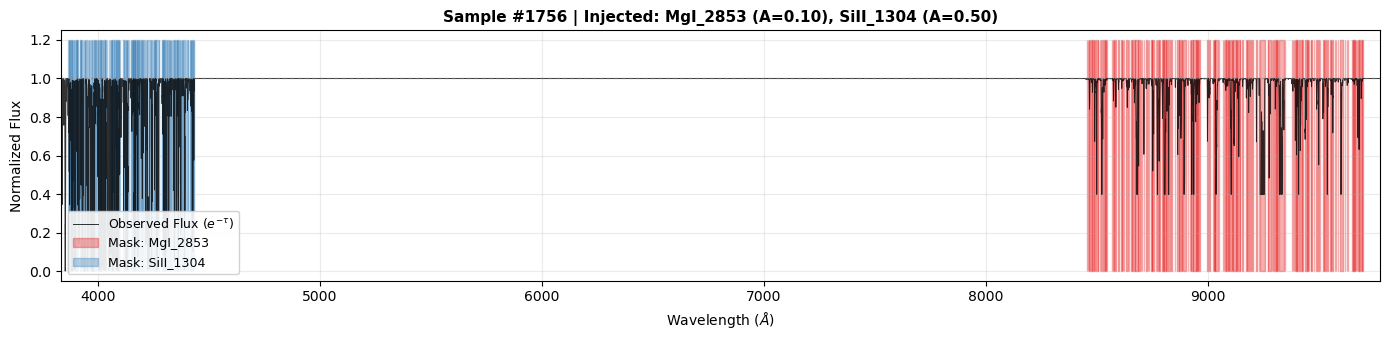

In [12]:
# plot example training data
plot_example_training_samples(
    dataset, 
    metal_dict = metal_dict,
    log_wave_grid = log_wave, 
    num_samples = 1,
    # zoom_margin_pixels: int = 250,
)

### Setting up the CNN Architecture

In [13]:
class ConvBlock1D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class SpectralUNet1D(nn.Module):
    def __init__(self, in_channels: int, num_species: int):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(in_channels, 32)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = ConvBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = ConvBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)
        
        # Bottleneck
        self.bottleneck = ConvBlock1D(128, 256)
        
        # Decoder
        self.dec3 = ConvBlock1D(256 + 128, 128)
        self.dec2 = ConvBlock1D(128 + 64, 64)
        self.dec1 = ConvBlock1D(64 + 32, 32)
        
        # Output Heads (1D convolutions with 1x1 kernel)
        self.cls_head = nn.Conv1d(32, num_species, kernel_size=1) # Logits
        self.reg_head = nn.Conv1d(32, num_species, kernel_size=1) # Amplitude log10(A)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        
        # Bottleneck
        b = self.bottleneck(self.pool3(e3))
        
        # Decoder with length-matched upsampling
        d3 = F.interpolate(b, size=e3.shape[-1], mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        # Heads
        mask_logits = self.cls_head(d1)
        amp_pred = self.reg_head(d1)
        
        return mask_logits, amp_pred

In [14]:
class CalibratedMultiMetalLoss(nn.Module):
    def __init__(self, pos_weight: float = 2.5, reg_weight: float = 1.0):
        super().__init__()
        self.register_buffer("pos_weight", torch.tensor([pos_weight]))
        self.reg_weight = reg_weight
        self.smooth_l1 = nn.SmoothL1Loss(reduction='sum')

    def forward(self, pred_logits, pred_amp, target_mask, target_amp):
        # 1. Classification Loss (Functional BCE avoids re-instantiating nn.Module every pass)
        loss_cls = F.binary_cross_entropy_with_logits(
            pred_logits, 
            target_mask, 
            pos_weight=self.pos_weight.to(pred_logits.device),
        )
        
        # 2. Boolean Indexing for Active Metal Pixels
        active_mask = target_mask > 0.5
        num_positives = active_mask.sum()

        if num_positives > 0:
            # Extract ONLY active pixels for regression loss
            loss_reg = self.smooth_l1(
                pred_amp[active_mask], 
                target_amp[active_mask])
        else:
            loss_reg = torch.tensor(0.0, device=pred_logits.device)
        
        # print("pred_logits:", pred_logits.device)
        # print("target_mask:", target_mask.device)
        # print("pos_weight:", self.pos_weight.device)
        
        total_loss = loss_cls + self.reg_weight * loss_reg
        return total_loss, loss_cls, loss_reg

# class CalibratedMultiMetalLoss(nn.Module):
#     def __init__(self, pos_weight: float = 2.5, reg_weight: float = 1.0):
#         super().__init__()
#         self.register_buffer("pos_weight_tensor", torch.tensor([pos_weight]))
#         self.reg_weight = reg_weight
#         self.smooth_l1 = nn.SmoothL1Loss(reduction='sum')

#     def forward(self, pred_logits, pred_amp, target_mask, target_amp):
#         bce_loss = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight_tensor.to(pred_logits.device))
#         loss_cls = bce_loss(pred_logits, target_mask)
        
#         num_positives = target_mask.sum() + 1e-6
#         masked_amp_diff = (pred_amp - target_amp) * target_mask
#         loss_reg = self.smooth_l1(masked_amp_diff, torch.zeros_like(masked_amp_diff)) / num_positives
        
#         total_loss = loss_cls + self.reg_weight * loss_reg
#         return total_loss, loss_cls, loss_reg

In [15]:
class DilatedBlock1D(nn.Module):
    """
    Multi-scale 1D block using dilated convolutions to expand receptive field
    for cross-correlating line profiles across forest clutter.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1, dilation=1)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=2, dilation=2)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.conv3 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=4, dilation=4)
        self.bn3   = nn.BatchNorm1d(out_ch)
        
        self.shortcut = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return F.relu(x + res)

class SpectralDilatedUNet1D(nn.Module):
    def __init__(self, in_channels: int, num_species: int):
        super().__init__()
        # Encoder
        self.enc1 = DilatedBlock1D(in_channels, 32)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = DilatedBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = DilatedBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)
        
        # Bottleneck
        self.bottleneck = DilatedBlock1D(128, 256)
        
        # Decoder
        self.dec3 = DilatedBlock1D(256 + 128, 128)
        self.dec2 = DilatedBlock1D(128 + 64, 64)
        self.dec1 = DilatedBlock1D(64 + 32, 32)
        
        # Output Heads
        self.cls_head = nn.Conv1d(32, num_species, kernel_size=1)
        self.reg_head = nn.Conv1d(32, num_species, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool3(e2))
        
        b = self.bottleneck(self.pool3(e3))
        
        d3 = F.interpolate(b, size=e3.shape[-1], mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        mask_logits = self.cls_head(d1)
        amp_pred = self.reg_head(d1)
        
        return mask_logits, amp_pred

In [16]:
epochs = 10

In [17]:
# # 2. Model, Loss, Optimizer
# num_channels = train_dataset[0][0].shape[0]  # e.g., 2 channels (1 raw + 1 shifted)
# num_species = train_dataset[0][1].shape[0]   # e.g., 1 species

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# # model = SpectralUNet1D(in_channels=num_channels, num_species=num_species).to(device)
# model = SpectralDilatedUNet1D(in_channels=num_channels, num_species=num_species).to(device)

# # Positional weight ~ 8.0 to balance 90% continuum vs 10% line pixels
# criterion = CalibratedMultiMetalLoss(pos_weight=2.5, reg_weight=1.0)
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [18]:
# 1. Train/Validation Split (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True) # Reduced batch size to 16 for memory
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)

# 2. Model, Loss, Optimizer
num_channels = dataset[0][0].shape[0]  # e.g., 2 channels (1 raw + 1 shifted)
num_species = dataset[0][1].shape[0]   # e.g., 1 species

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

# model = SpectralUNet1D(in_channels=num_channels, num_species=num_species).to(device)
model = SpectralDilatedUNet1D(in_channels=num_channels, num_species=num_species).to(device)


# Positional weight ~ 8.0 to balance 90% continuum vs 10% line pixels
criterion = CalibratedMultiMetalLoss(pos_weight=2.5, reg_weight=1.0).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [19]:
print("model:", next(model.parameters()).device)
print("loss:", criterion.pos_weight.device)

model: cuda:0
loss: cuda:0


In [20]:
# Setup save paths and config metadata
# checkpoint_path = "MgI_SiII_A_0-02__0-05.pt"
checkpoint_path = "MgI_SiII_test_3.pt"

config_metadata = {
    "in_channels": num_channels,
    "num_species": num_species,
    # "metal_dict": {'MgI_2853': 2852.96, 'SiII(1304)': 1304.3702},
    'metal_dict': metal_dict,
    "lya_wave": 1215.67
}

best_val_loss = float("inf")

In [21]:
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 3. Training Loop
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()
    train_loss, train_cls, train_reg = 0.0, 0.0, 0.0
    
    for X_b, mask_b, amp_b in train_loader:
        X_b, mask_b, amp_b = X_b.to(device), mask_b.to(device), amp_b.to(device)
        
        optimizer.zero_grad()
        pred_logits, pred_amp = model(X_b)
        
        loss, l_cls, l_reg = criterion(pred_logits, pred_amp, mask_b, amp_b)
        loss.backward()
        
        # Clip gradients to prevent loss spikes/instability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * X_b.size(0)
        train_cls += l_cls.item() * X_b.size(0)
        train_reg += l_reg.item() * X_b.size(0)

    # Validation phase
    model.eval()
    val_loss, val_cls, val_reg = 0.0, 0.0, 0.0
    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b, mask_b, amp_b = X_b.to(device), mask_b.to(device), amp_b.to(device)
            
            pred_logits, pred_amp = model(X_b)
            loss, l_cls, l_reg = criterion(pred_logits, pred_amp, mask_b, amp_b)
            
            val_loss += loss.item() * X_b.size(0)
            val_cls += l_cls.item() * X_b.size(0)
            val_reg += l_reg.item() * X_b.size(0)

    scheduler.step()
    
    # Normalize losses by number of samples
    train_loss /= len(train_set)
    train_cls  /= len(train_set)
    train_reg  /= len(train_set)
    
    val_loss /= len(val_set)
    val_cls  /= len(val_set)
    val_reg  /= len(val_set)
    
    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} "
        f"(Cls: {val_cls:.4f}, Reg: {val_reg:.4f})"
    )
    
    # Checkpoint based on normalized validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_model_checkpoint(
            filepath=checkpoint_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            val_loss=val_loss,
            config=config_metadata
        )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} (Cls: {val_cls:.4f}, Reg: {val_reg:.4f})"
        )
        

Epoch 01/10 | Train Loss: 243.9875 | Val Loss: 27.0061 (Cls: 0.5346, Reg: 26.4715)
--> Saved checkpoint to 'MgI_SiII_test_3.pt' (Epoch 1, Val Loss: 27.0061)
Epoch 02/10 | Train Loss: 15.3546 | Val Loss: 10.7180 (Cls: 0.4344, Reg: 10.2837)
--> Saved checkpoint to 'MgI_SiII_test_3.pt' (Epoch 2, Val Loss: 10.7180)
Epoch 03/10 | Train Loss: 7.3303 | Val Loss: 1.6521 (Cls: 0.3537, Reg: 1.2984)
--> Saved checkpoint to 'MgI_SiII_test_3.pt' (Epoch 3, Val Loss: 1.6521)
Epoch 04/10 | Train Loss: 5.1344 | Val Loss: 1.8665 (Cls: 0.3400, Reg: 1.5265)
Epoch 05/10 | Train Loss: 2.2511 | Val Loss: 1.1475 (Cls: 0.3232, Reg: 0.8243)
--> Saved checkpoint to 'MgI_SiII_test_3.pt' (Epoch 5, Val Loss: 1.1475)
Epoch 05/10 | Train Loss: 2.2511 | Val Loss: 1.1475 (Cls: 0.3232, Reg: 0.8243)
Epoch 06/10 | Train Loss: 2.5582 | Val Loss: 0.5889 (Cls: 0.3190, Reg: 0.2699)
--> Saved checkpoint to 'MgI_SiII_test_3.pt' (Epoch 6, Val Loss: 0.5889)
Epoch 07/10 | Train Loss: 1.2023 | Val Loss: 0.7637 (Cls: 0.3047, Reg: 0.

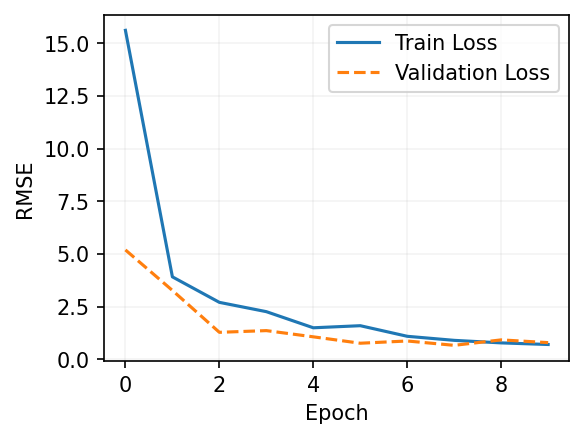

In [22]:
# Plot train / validation loss
plt.figure(figsize=(4,3), dpi=150)
plt.plot(np.sqrt(train_losses), label='Train Loss')
plt.plot(np.sqrt(val_losses), label='Validation Loss', ls='dashed')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
# plt.ylim(0.09, 0.5)
plt.grid(alpha=0.15)
plt.legend()
plt.show()

#### Run some diagnostics

In [23]:
def is_valid_spectrum_detection(prob_array, p_thresh=0.5, min_contiguous_pixels=3):
    """
    Returns True only if there are at least `min_contiguous_pixels`
    consecutively exceeding p_thresh in the spectrum.
    """
    binary_mask = prob_array >= p_thresh
    labeled_array, num_features = label(binary_mask)
    
    if num_features == 0:
        return False
    
    for feature_idx in range(1, num_features + 1):
        if np.sum(labeled_array == feature_idx) >= min_contiguous_pixels:
            return True
            
    return False

In [38]:
def evaluate_unet_stats(
    model, 
    val_loader, 
    device, 
    metal_names: list = None, 
    ):

    model.eval()

    all_mask_true = []
    all_amp_true  = []
    all_prob_pred = []
    all_amp_pred  = []

    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b = X_b.to(device)
            logits_pred, amp_pred = model(X_b)
            probs_pred = torch.sigmoid(logits_pred)

            all_mask_true.append(mask_b.cpu().numpy())
            all_amp_true.append(amp_b.cpu().numpy())
            all_prob_pred.append(probs_pred.cpu().numpy())
            all_amp_pred.append(amp_pred.cpu().numpy())

    # Stack shapes -> (N_spectra, M_species, N_pixels)
    mask_true = np.concatenate(all_mask_true, axis=0)
    amp_true  = np.concatenate(all_amp_true, axis=0)
    prob_pred = np.concatenate(all_prob_pred, axis=0)
    amp_pred  = np.concatenate(all_amp_pred, axis=0)

    prob_threshes = []

    ###############################################

    # print("\n=== SHAPE / SPECIES DEBUG ===")
    # print("mask_true:", mask_true.shape)
    # print("amp_true: ", amp_true.shape)
    # print("prob_pred:", prob_pred.shape)
    # print("amp_pred: ", amp_pred.shape)
    # print("metal_names:", metal_names)
    # print("species_names; ", species_names)
    # print("prob_pred shape:", prob_pred.shape)
    # print("mask_true shape:", mask_true.shape)
    
    fig, ax = plt.subplots(figsize=(8, 5))

    for m_idx, name in enumerate(metal_names):
        gt_spec = np.any(mask_true[:, m_idx, :] > 0.5, axis=1)
        max_prob = prob_pred[:, m_idx, :].max(axis=1)
    
        print(f"\n{name}")
        print("  GT spectra:", gt_spec.sum())
        print("  mean max prob, GT:", max_prob[gt_spec].mean())
        print("  mean max prob, non-GT:", max_prob[~gt_spec].mean())
        print("  median max prob, GT:", np.median(max_prob[gt_spec]))
        print("  median max prob, non-GT:", np.median(max_prob[~gt_spec]))

        prob_threshes.append(max_prob[gt_spec].mean())
    
        for threshold in [0.20, 0.25, 0.27, 0.28, 0.29, 0.30]:
            pred = max_prob >= threshold
            tp = np.sum(gt_spec & pred)
            fp = np.sum(~gt_spec & pred)
            fn = np.sum(gt_spec & ~pred)
    
            purity = tp / (tp + fp) if tp + fp else 0
            completeness = tp / (tp + fn) if tp + fn else 0
    
            print(
                f"  p>{threshold:.2f}: "
                f"pred={pred.sum():4d}, "
                f"purity={purity:.3f}, "
                f"completeness={completeness:.3f}"
            )
            
        ax.hist(
            max_prob[gt_spec],
            bins=30,
            alpha=0.5,
            label=f"{name} — GT"
        )
        ax.hist(
            max_prob[~gt_spec],
            bins=30,
            alpha=0.5,
            label=f"{name} — no GT"
        )
        ax.axvline(max_prob[gt_spec].mean(), linestyle="--", label=f"{name} mean", color='k')
    
    # ax.axvline(0.5, linestyle="--", label="threshold")
    ax.set_xlabel("Maximum predicted probability per spectrum")
    ax.set_ylabel("Number of spectra")
    ax.legend()
    plt.show()

    for m_idx, name in enumerate(metal_names):
        print(name, "spectra with GT:", np.sum(np.any(mask_true[:, m_idx, :] > 0.5, axis=-1)), "/", mask_true.shape[0])
        print(name, "mean amp_true on GT pixels:", amp_true[:, m_idx, :][mask_true[:, m_idx, :] > 0.5].mean() if np.any(mask_true[:,m_idx,:]>0.5) else "N/A")
    
    print("MgI max prob per spectrum:", np.percentile(prob_pred[:, 0, :].max(axis=-1), [50, 90, 99]))
    print("SiII max prob per spectrum:", np.percentile(prob_pred[:, 1, :].max(axis=-1), [50, 90, 99]))
    
    ###############################################
    
    return(prob_threshes)



In [47]:
def evaluate_fixed_amplitude_unet(
    model, 
    val_loader, 
    device, 
    metal_names: list = None, 
    prob_thresh: Union[float, Dict[str, float], List[float]] = 0.5,
    min_contiguous_pixels: Union[int, Dict[str, int], List[int]] = 3,
    inputs_in_log_space: bool = True,
):
    """
    Evaluates a 1D U-Net on a dataset with fixed single-amplitude metal lines per species.
    Reports all metrics and generates plots in linear amplitude units A using spatial filtering.
    
    `prob_thresh` and `min_contiguous_pixels` can be passed as:
      - A single scalar (applied to all species)
      - A dict mapping species names to values, e.g., {'SiII_1260': 0.85, 'MgI_2853': 0.50}
      - A list matching the order of `metal_names`
    """
    model.eval()

    all_mask_true = []
    all_amp_true  = []
    all_prob_pred = []
    all_amp_pred  = []

    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b = X_b.to(device)
            logits_pred, amp_pred = model(X_b)
            probs_pred = torch.sigmoid(logits_pred)

            all_mask_true.append(mask_b.cpu().numpy())
            all_amp_true.append(amp_b.cpu().numpy())
            all_prob_pred.append(probs_pred.cpu().numpy())
            all_amp_pred.append(amp_pred.cpu().numpy())

    # Stack shapes -> (N_spectra, M_species, N_pixels)
    mask_true = np.concatenate(all_mask_true, axis=0)
    amp_true  = np.concatenate(all_amp_true, axis=0)
    prob_pred = np.concatenate(all_prob_pred, axis=0)
    amp_pred  = np.concatenate(all_amp_pred, axis=0)

    ###############################################

    # Convert from log10 space to linear amplitude A if needed
    if inputs_in_log_space:
        amp_true = 10.0 ** amp_true
        amp_pred = 10.0 ** amp_pred

    num_spectra, num_species, _ = mask_true.shape
    if metal_names is None:
        metal_names = [f"Species_{i+1}" for i in range(num_species)]

    for m_idx, species_name in enumerate(metal_names):
        # --- Resolve per-species probability threshold ---
        if isinstance(prob_thresh, dict):
            current_p_thresh = prob_thresh.get(species_name, 0.5)
        elif isinstance(prob_thresh, (list, tuple)):
            current_p_thresh = prob_thresh[m_idx]
        else:
            current_p_thresh = float(prob_thresh)

        # --- Resolve per-species min_contiguous_pixels ---
        if isinstance(min_contiguous_pixels, dict):
            current_min_contig = min_contiguous_pixels.get(species_name, 3)
        elif isinstance(min_contiguous_pixels, (list, tuple)):
            current_min_contig = min_contiguous_pixels[m_idx]
        else:
            current_min_contig = int(min_contiguous_pixels)

        # Flattened arrays for pixel calculations
        m_mask_true = mask_true[:, m_idx, :].flatten()
        m_amp_true  = amp_true[:, m_idx, :].flatten()
        m_prob_pred = prob_pred[:, m_idx, :].flatten()
        m_amp_pred  = amp_pred[:, m_idx, :].flatten()

        is_true = m_mask_true > 0.5
        is_pred = m_prob_pred >= current_p_thresh
        is_tp   = is_true & is_pred

        # --- 1. Pixel-Level Classification Metrics ---
        tp = np.sum(is_tp)
        fp = np.sum(~is_true & is_pred)
        fn = np.sum(is_true & ~is_pred)
        tn = np.sum(~is_true & ~is_pred)
        
        purity = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        completeness = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        # --- 1. Spectrum-Level Classification with Contiguous Thresholding ---
        spec_has_gt   = np.any(mask_true[:, m_idx, :] > 0.5, axis=-1)  # Shape: (N_spectra,)
        spec_max_prob = np.max(prob_pred[:, m_idx, :], axis=-1)       # Shape: (N_spectra,)
        
        # Apply spatial contiguity detection rule across all spectra
        spec_is_pred = np.array([
            is_valid_spectrum_detection(
                prob_pred[s_idx, m_idx, :], 
                p_thresh=current_p_thresh, 
                min_contiguous_pixels=current_min_contig
            )
            for s_idx in range(num_spectra)
        ])

        tp_spec = np.sum(spec_has_gt & spec_is_pred)
        fp_spec = np.sum(~spec_has_gt & spec_is_pred)
        fn_spec = np.sum(spec_has_gt & ~spec_is_pred)
        tn_spec = np.sum(~spec_has_gt & ~spec_is_pred)

        spec_purity = tp_spec / (tp_spec + fp_spec) if (tp_spec + fp_spec) > 0 else 0.0
        spec_completeness = tp_spec / (tp_spec + fn_spec) if (tp_spec + fn_spec) > 0 else 0.0

        # Extract 1 amplitude per detected true positive spectrum
        spec_true_a0 = []
        spec_pred_amps_tp = []
        spec_pred_probs_tp = []

        for s_idx in range(num_spectra):
            gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
            tp_pixels = gt_pixels & (prob_pred[s_idx, m_idx, :] >= current_p_thresh)

            if np.any(gt_pixels):
                spec_true_a0.append(np.median(amp_true[s_idx, m_idx, gt_pixels]))

                if spec_is_pred[s_idx] and np.any(tp_pixels):
                    spec_pred_amps_tp.append(np.median(amp_pred[s_idx, m_idx, tp_pixels]))
                    spec_pred_probs_tp.append(spec_max_prob[s_idx])

        true_a0 = np.median(spec_true_a0) if len(spec_true_a0) > 0 else 0.0
        spec_pred_amps_tp = np.array(spec_pred_amps_tp)
        spec_pred_probs_tp = np.array(spec_pred_probs_tp)

        # Statistics on spectrum-level predictions
        if len(spec_pred_amps_tp) > 0:
            pred_median = np.median(spec_pred_amps_tp)
            p16, p84 = np.percentile(spec_pred_amps_tp, [16, 84])
            sigma_68 = (p84 - p16) / 2.0
            bias = pred_median - true_a0
            spec_mae = np.mean(np.abs(spec_pred_amps_tp - true_a0))
        else:
            pred_median, p16, p84, sigma_68, bias, spec_mae = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

        # --- 2. Print Summary Metrics ---
        print("\n" + "="*60)
        print(f" FIXED AMPLITUDE METRICS: {species_name} (True A0 = {true_a0:.4f})")
        print("="*60)
        print(f" SPECTRUM-LEVEL CLASSIFICATION (p >= {current_p_thresh:.2f}, Min Contiguous = {current_min_contig} px):")
        print(f"   True Positives:  {tp_spec:4d} | False Positives: {fp_spec:4d}")
        print(f"   False Negatives: {fn_spec:4d} | True Negatives:  {tn_spec:4d}")
        print(f"   Purity (Precision):    {spec_purity:.4f}")
        print(f"   Completeness (Recall): {spec_completeness:.4f}")
        print("-" * 60)
        print(" PIXEL-LEVEL CLASSIFICATION:")
        print(f"  True Positives:  {tp:8d} | False Positives: {fp:8d}")
        print(f"  False Negatives: {fn:8d} | True Negatives:  {tn:8d}")
        print(f"  Purity (Precision):    {purity:.4f}")
        print(f"  Completeness (Recall): {completeness:.4f}")
        print("-" * 60)
        print(" SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):")
        print(f"   Detected Spectra (TPs):    {len(spec_pred_amps_tp)} / {np.sum(spec_has_gt)}")
        print(f"   Predicted Amplitude Median: {pred_median:.4f}")
        print(f"   Global Bias (Pred - True):  {bias:+.4f}")
        print(f"   68% Spread (sigma_68):     {sigma_68:.4f}")
        print(f"   Spectrum Amplitude MAE:     {spec_mae:.4f}")
        print("="*60)

        # --- 3. Diagnostics Plotting (2x2 Panel per metal) ---
        fig, axes = plt.subplots(2, 2, figsize=(13, 11))

        # Panel 1: Pixel-Level Linear Residual Distribution
        if np.sum(is_tp) > 0:
            pix_residuals = m_amp_pred[is_tp] - m_amp_true[is_tp]
            axes[0, 0].hist(pix_residuals, bins=50, density=True, color="steelblue", alpha=0.7, edgecolor="black")
            axes[0, 0].axvline(0, color="red", linestyle="--", lw=2, label="Zero Bias")
            axes[0, 0].axvline(np.median(pix_residuals), color="darkblue", linestyle="-", lw=2, 
                               label=f"Pixel Median ({np.median(pix_residuals):+.4f})")
            axes[0, 0].set_xlabel(r"Pixel Residual ($A_{\mathrm{pred}} - A_0$)")
            axes[0, 0].set_ylabel("Probability Density")
            axes[0, 0].set_title(f"Pixel-Level Residuals (True Positives)\nMAE: {np.mean(np.abs(pix_residuals)):.4f}")
            axes[0, 0].grid(True, alpha=0.3)
            # axes[0, 0].set_xlim(-0.1, 0.1)
            axes[0, 0].set_xlim(pix_residuals.min(), pix_residuals.max())
            axes[0, 0].legend(loc="upper right")
        else:
            axes[0, 0].text(0.5, 0.5, "No True Positives", ha="center", va="center")

        # Panel 2: Spectrum-Level Linear Amplitude Distribution
        if len(spec_pred_amps_tp) > 0:
            axes[0, 1].hist(spec_pred_amps_tp, bins=30, density=True, color="mediumpurple", alpha=0.7, edgecolor="black")
            axes[0, 1].axvline(true_a0, color="red", linestyle="--", lw=2, label=f"True $A_0$ ({true_a0:.4f})")
            axes[0, 1].axvline(pred_median, color="indigo", linestyle="-", lw=2, label=f"Pred Median ({pred_median:.4f})")
            axes[0, 1].axvspan(p16, p84, color="mediumpurple", alpha=0.25, label=f"68% CI [{p16:.3f}, {p84:.3f}]")
            axes[0, 1].set_xlabel("Predicted Spectrum Amplitude ($A$)")
            axes[0, 1].set_ylabel("Probability Density")
            axes[0, 1].set_title(f"Spectrum-Level Amplitude Recovery\nBias: {bias:+.4f} | $\sigma_{{68}}$: {sigma_68:.4f}")
            axes[0, 1].grid(True, alpha=0.3)
            axes[0, 1].legend(loc="upper right")
        else:
            axes[0, 1].text(0.5, 0.5, "No Detected Spectra", ha="center", va="center")

        # Panel 3: Spectrum-Level Purity & Completeness Curves (Contiguous Sweep)
        prob_sweep = np.linspace(0.01, 0.99, 50)
        purities_spec, completenesses_spec = [], []
        
        for p_th in prob_sweep:
            spec_pred_i = np.array([
                is_valid_spectrum_detection(
                    prob_pred[s_idx, m_idx, :], 
                    p_thresh=p_th, 
                    min_contiguous_pixels=current_min_contig
                )
                for s_idx in range(num_spectra)
            ])
            tp_i = np.sum(spec_has_gt & spec_pred_i)
            fp_i = np.sum(~spec_has_gt & spec_pred_i)
            fn_i = np.sum(spec_has_gt & ~spec_pred_i)
            
            purities_spec.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
            completenesses_spec.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

        axes[1, 0].plot(prob_sweep, purities_spec, label="Spectrum Purity", color="teal", lw=2)
        axes[1, 0].plot(prob_sweep, completenesses_spec, label="Spectrum Completeness", color="darkorange", lw=2)
        axes[1, 0].axvline(current_p_thresh, color="gray", linestyle=":", label=f"Current Thresh ({current_p_thresh:.2f})")
        axes[1, 0].set_xlabel("Detection Probability Threshold")
        axes[1, 0].set_ylabel("Fraction")
        axes[1, 0].set_title(f"Spectrum-Level Purity & Completeness\n(Min Contiguous = {current_min_contig} px)")
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend(loc="best")

        # Panel 4: Pixel-Level Purity & Completeness Curves
        prob_sweep = np.linspace(0.01, 0.99, 50)
        purities, completenesses = [], []
        for p_th in prob_sweep:
            pred_pos = m_prob_pred >= p_th
            tp_i = np.sum(is_true & pred_pos)
            fp_i = np.sum(~is_true & pred_pos)
            fn_i = np.sum(is_true & ~pred_pos)
            
            purities.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
            completenesses.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

        axes[1, 1].plot(prob_sweep, purities, label="Pixel Purity", color="teal", lw=2)
        axes[1, 1].plot(prob_sweep, completenesses, label="Pixel Completeness", color="darkorange", lw=2)
        axes[1, 1].axvline(current_p_thresh, color="gray", linestyle=":", label=f"Thresh ({current_p_thresh:.2f})")
        axes[1, 1].set_xlabel("Detection Probability Threshold")
        axes[1, 1].set_ylabel("Fraction")
        axes[1, 1].set_title("Pixel-Level Purity & Completeness")
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend(loc="best")

        plt.suptitle(f"Fixed-Amplitude Diagnostic Summary: {species_name}", fontsize=14, y=0.99)
        plt.tight_layout()
        plt.show()

### Load an existing model

In [27]:
# Test on the Validation dataset

# checkpoint_path = "MgI_SiII_A_0-1__0-5.pt"
# checkpoint_path = "SiII_CIV_A_1_5_test.pt"
checkpoint_path = "MgI_SiII_test_3.pt"


model, checkpoint = load_model_checkpoint(
    checkpoint_path,
    device=device,
    model_class=SpectralDilatedUNet1D
)

model.eval()

species_names = list(metal_dict.keys())  # ['MgI_2853', 'SiII(1304)']
species_names

--> Loaded checkpoint 'MgI_SiII_test_3.pt' (Trained for 8 epochs, Val Loss: 0.4456)


['MgI_2853', 'SiII_1304']


MgI_2853
  GT spectra: 756
  mean max prob, GT: 0.25199267
  mean max prob, non-GT: 0.2531788
  median max prob, GT: 0.25294703
  median max prob, non-GT: 0.251747
  p>0.20: pred=1000, purity=0.756, completeness=1.000
  p>0.25: pred= 562, purity=0.758, completeness=0.563
  p>0.27: pred=   9, purity=0.889, completeness=0.011
  p>0.28: pred=   0, purity=0.000, completeness=0.000
  p>0.29: pred=   0, purity=0.000, completeness=0.000
  p>0.30: pred=   0, purity=0.000, completeness=0.000

SiII_1304
  GT spectra: 715
  mean max prob, GT: 0.727065
  mean max prob, non-GT: 0.7297272
  median max prob, GT: 0.7387006
  median max prob, non-GT: 0.7396225
  p>0.20: pred=1000, purity=0.715, completeness=1.000
  p>0.25: pred=1000, purity=0.715, completeness=1.000
  p>0.27: pred=1000, purity=0.715, completeness=1.000
  p>0.28: pred=1000, purity=0.715, completeness=1.000
  p>0.29: pred=1000, purity=0.715, completeness=1.000
  p>0.30: pred=1000, purity=0.715, completeness=1.000


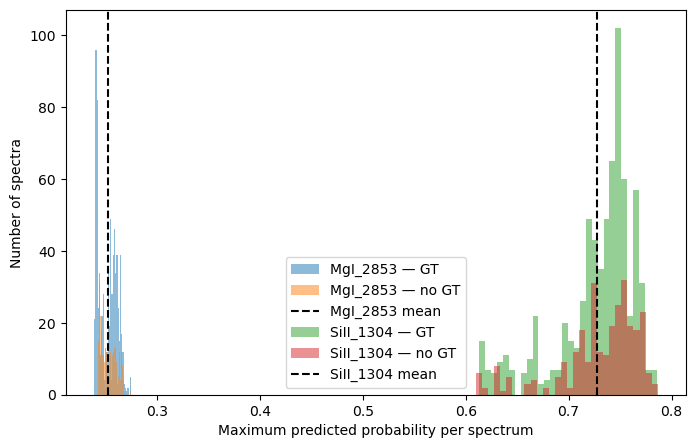

MgI_2853 spectra with GT: 756 / 1000
MgI_2853 mean amp_true on GT pixels: -1.0
SiII_1304 spectra with GT: 715 / 1000
SiII_1304 mean amp_true on GT pixels: -0.30103037
MgI max prob per spectrum: [0.25276333 0.26426187 0.26992187]
SiII max prob per spectrum: [0.73879892 0.76698182 0.7789185 ]


In [39]:
prob_threshes = evaluate_unet_stats(
    model=model,
    val_loader=val_loader,
    device=device,
    metal_names=species_names,
)

In [42]:
prob_threshes

[0.25199267, 0.727065]


 FIXED AMPLITUDE METRICS: MgI_2853 (True A0 = 0.1000)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.22, Min Contiguous = 3 px):
   True Positives:   756 | False Positives:  244
   False Negatives:    0 | True Negatives:     0
   Purity (Precision):    0.7560
   Completeness (Recall): 1.0000
------------------------------------------------------------
 PIXEL-LEVEL CLASSIFICATION:
  True Positives:   1581447 | False Positives:  5755670
  False Negatives:    21481 | True Negatives:  23642402
  Purity (Precision):    0.2155
  Completeness (Recall): 0.9866
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):
   Detected Spectra (TPs):    756 / 756
   Predicted Amplitude Median: 0.1002
   Global Bias (Pred - True):  +0.0002
   68% Spread (sigma_68):     0.0000
   Spectrum Amplitude MAE:     0.0002


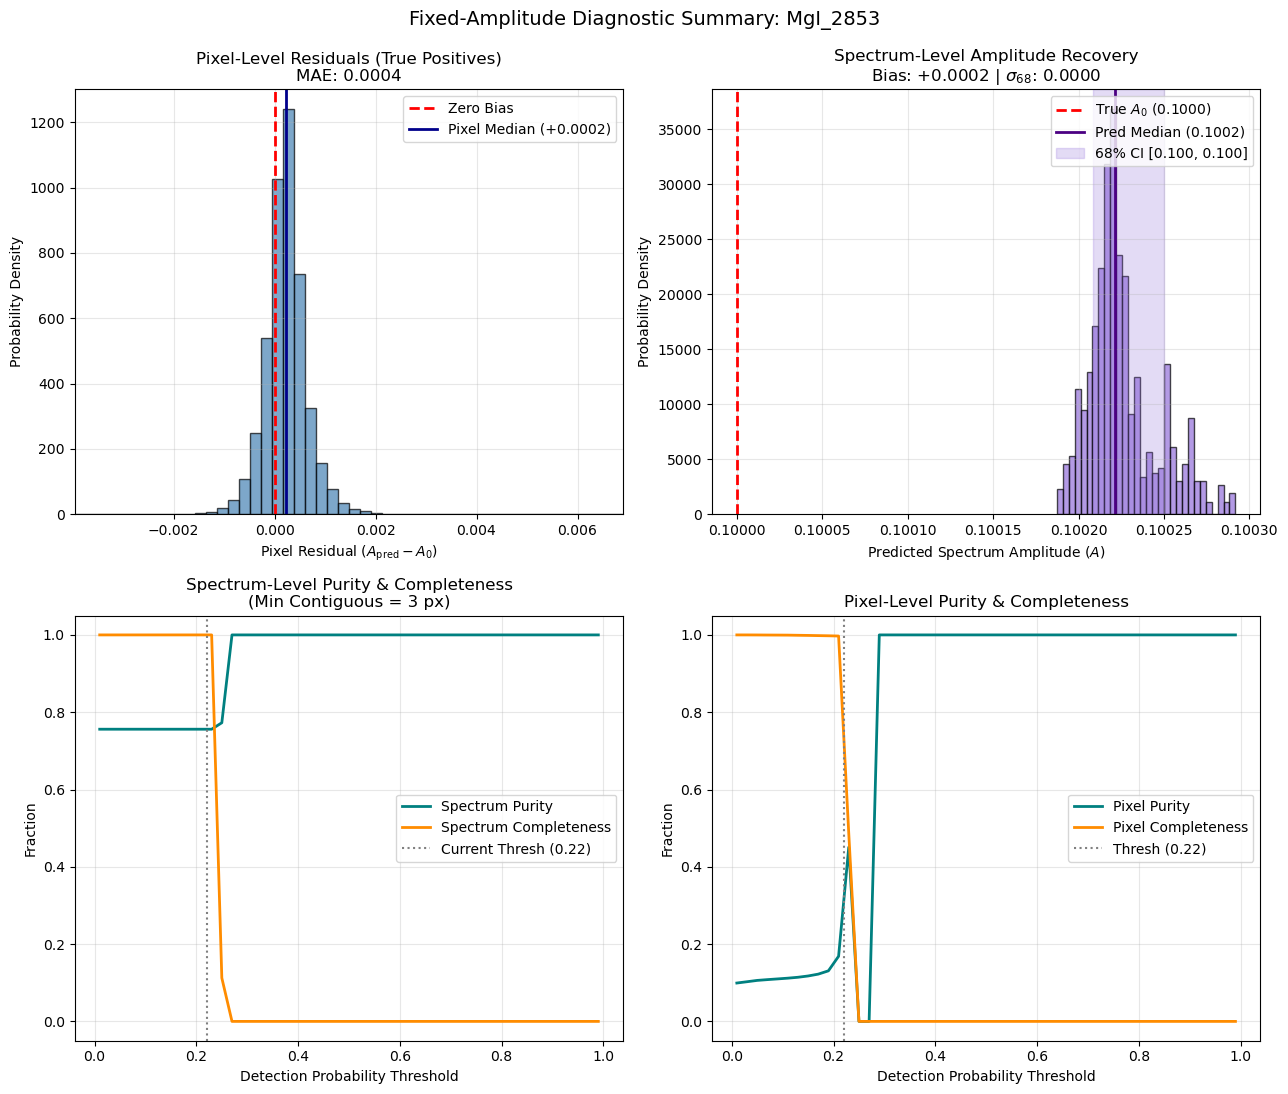


 FIXED AMPLITUDE METRICS: SiII_1304 (True A0 = 0.5000)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.70, Min Contiguous = 3 px):
   True Positives:   534 | False Positives:  215
   False Negatives:  181 | True Negatives:    70
   Purity (Precision):    0.7130
   Completeness (Recall): 0.7469
------------------------------------------------------------
 PIXEL-LEVEL CLASSIFICATION:
  True Positives:      5181 | False Positives:    12619
  False Negatives:  2343994 | True Negatives:  28639206
  Purity (Precision):    0.2911
  Completeness (Recall): 0.0022
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):
   Detected Spectra (TPs):    391 / 715
   Predicted Amplitude Median: 0.4969
   Global Bias (Pred - True):  -0.0031
   68% Spread (sigma_68):     0.0014
   Spectrum Amplitude MAE:     0.0031


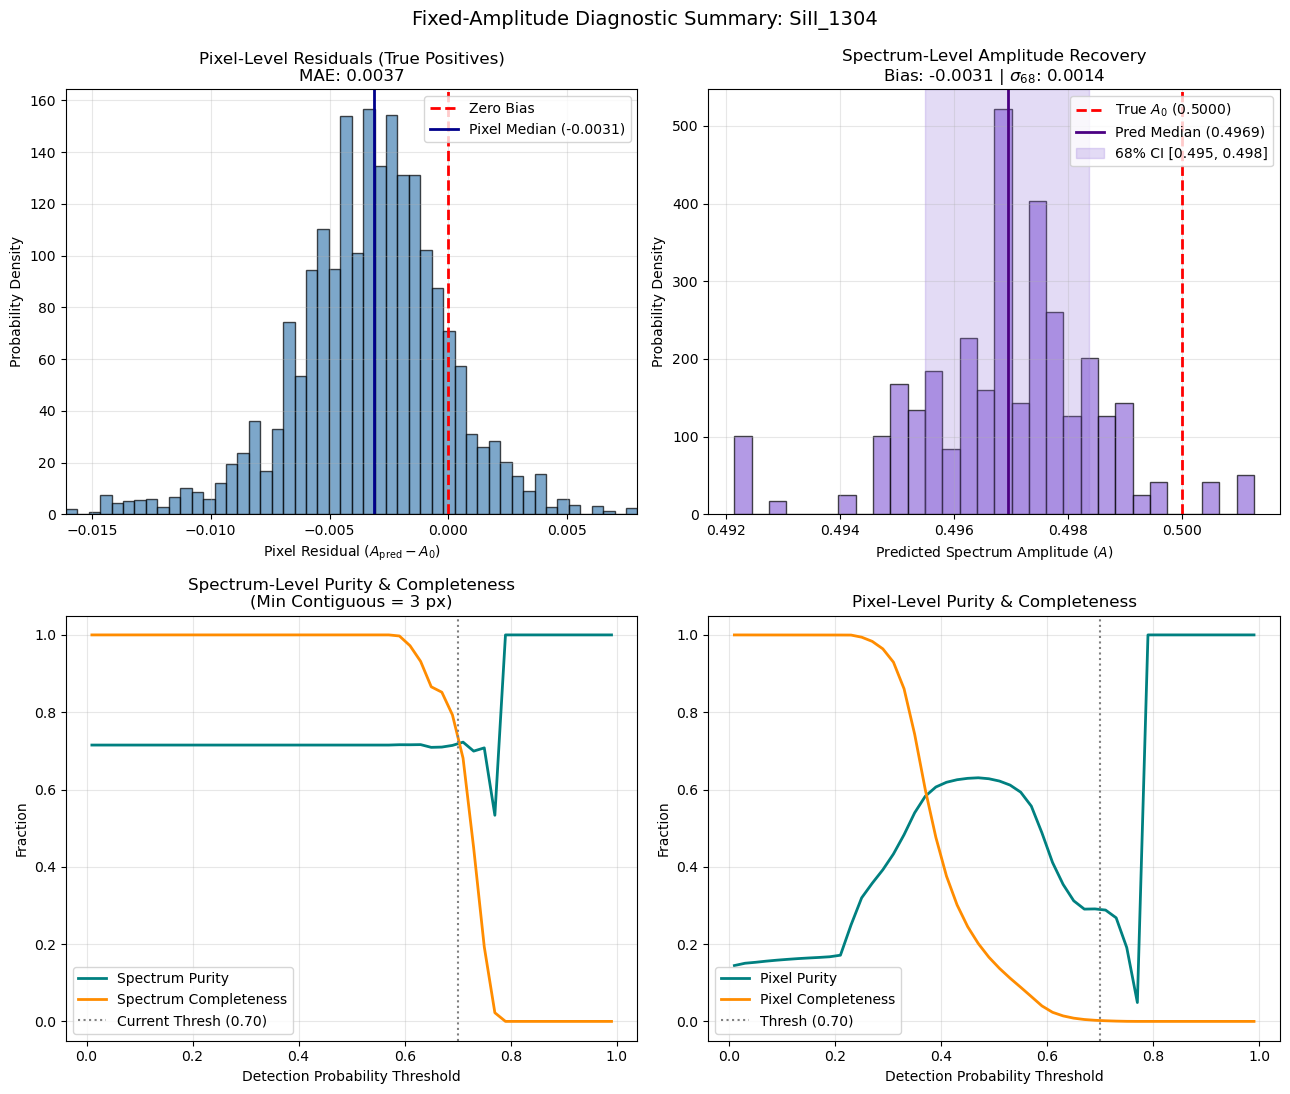

In [48]:
evaluate_fixed_amplitude_unet(
    model=model,
    val_loader=val_loader,
    device=device,
    metal_names=species_names,
    prob_thresh = [0.22, 0.7],
    min_contiguous_pixels=3,
)

--> Loaded checkpoint 'MgI_SiII_A_1_05_test.pt' (Trained for 10 epochs, Val Loss: 0.7498)

 FIXED AMPLITUDE METRICS: MgI_2853 (True A0 = 0.1000)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.50, Min Contiguous = 1 px):
   True Positives:     0 | False Positives:    0
   False Negatives: 2799 | True Negatives:  2201
   Purity (Precision):    0.0000
   Completeness (Recall): 0.0000
------------------------------------------------------------
 PIXEL-LEVEL CLASSIFICATION:
  True Positives:         0 | False Positives:        0
  False Negatives:  5924990 | True Negatives:  149080010
  Purity (Precision):    0.0000
  Completeness (Recall): 0.0000
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):
   Detected Spectra (TPs):    0 / 2799
   Predicted Amplitude Median: 0.0000
   Global Bias (Pred - True):  +0.0000
   68% Spread (sigma_68):     0.0000
   Spectrum Amplitude MAE:     0.0000


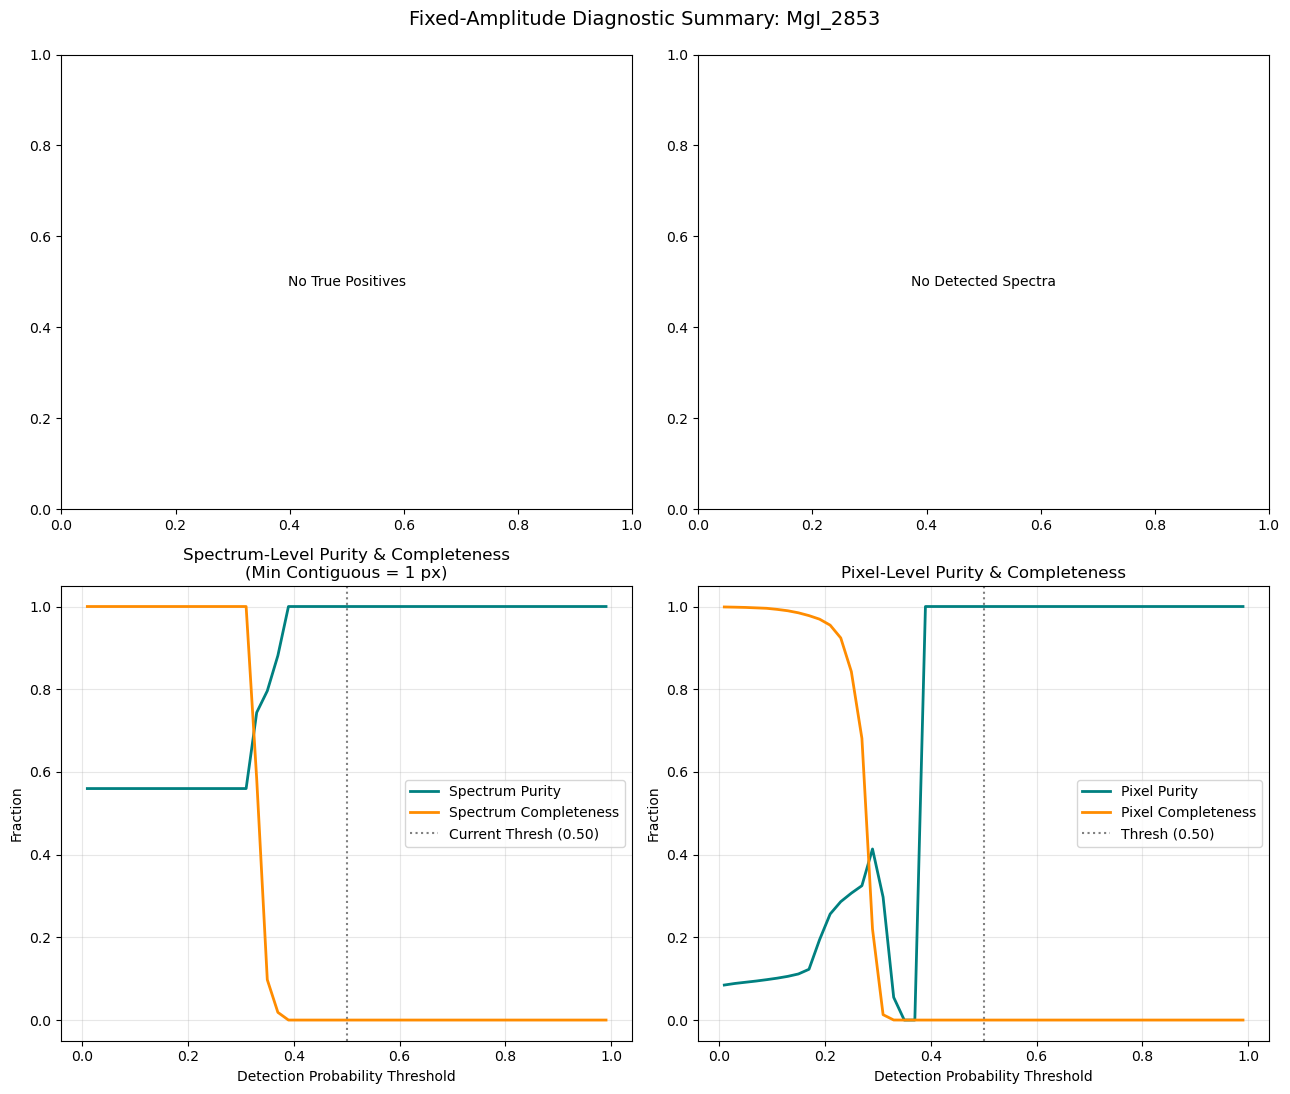


 FIXED AMPLITUDE METRICS: SiII_1304 (True A0 = 0.5000)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.50, Min Contiguous = 1 px):
   True Positives:  2847 | False Positives: 2153
   False Negatives:    0 | True Negatives:     0
   Purity (Precision):    0.5694
   Completeness (Recall): 1.0000
------------------------------------------------------------
 PIXEL-LEVEL CLASSIFICATION:
  True Positives:    220499 | False Positives:   205702
  False Negatives:  9339036 | True Negatives:  145239763
  Purity (Precision):    0.5174
  Completeness (Recall): 0.0231
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):
   Detected Spectra (TPs):    2847 / 2847
   Predicted Amplitude Median: 0.0498
   Global Bias (Pred - True):  -0.4502
   68% Spread (sigma_68):     0.0003
   Spectrum Amplitude MAE:     0.4502



KeyboardInterrupt



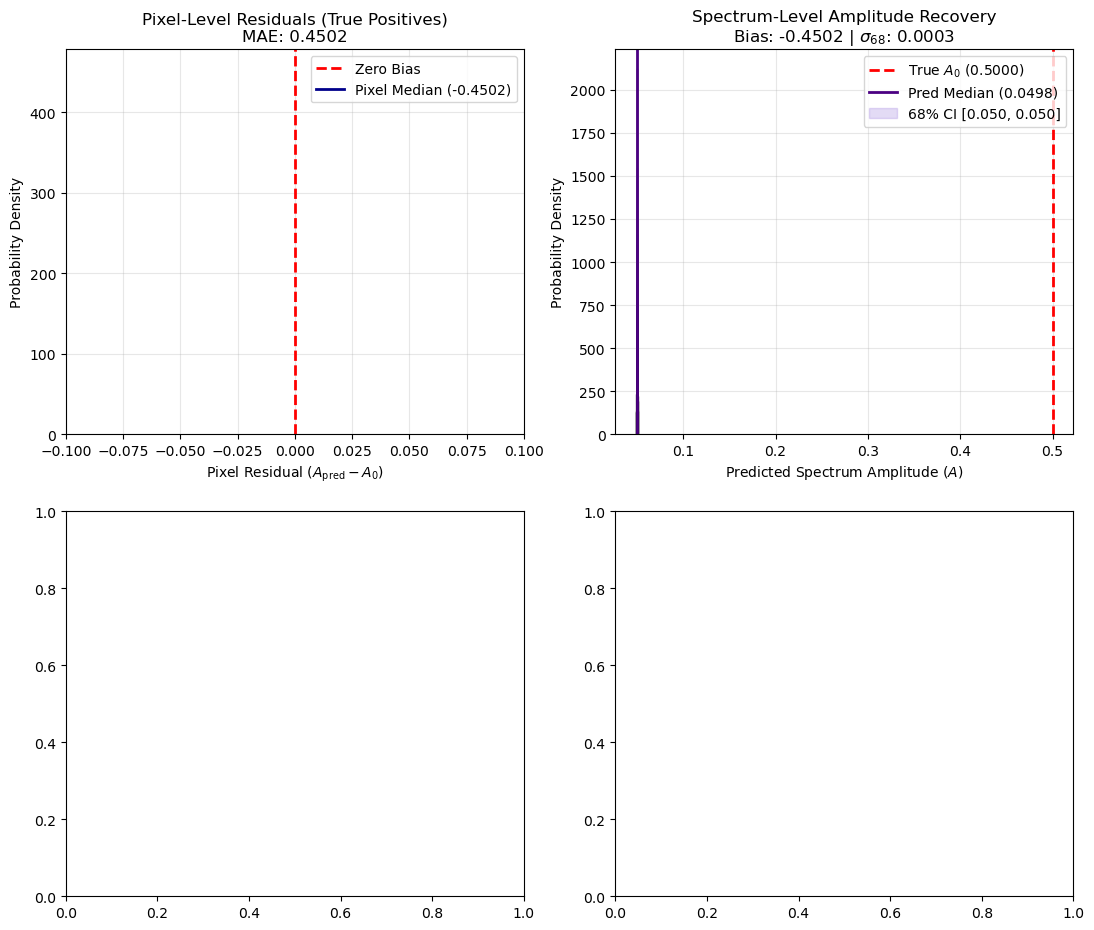

In [26]:
# Test on separate external dataset

checkpoint_path = "MgI_SiII_A_1_05_test.pt"

model, _ = load_model_checkpoint(checkpoint_path,
                                 device=device, 
                                 model_class=SpectralDilatedUNet1D)

test_dataset = generate_multimetal_dataset(
    lya_flux_samples=fluxes_log,
    log_wave_grid=log_wave,
    metal_dict=metal_dict,
    a_min=[0.1, 0.5], 
    a_max=[0.1, 0.5],
    num_samples=5000,
    max_metals_per_spectrum=max_metals_per_spectrum,
    snr=None,
    tau_min_fraction=tau_min_fraction,
    zero_metal_prob=zero_metal_prob,
)

test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

species_names = list(metal_dict.keys())  # ['MgI_2853', 'SiII(1304)']

# 2. Run diagnostics directly
evaluate_fixed_amplitude_unet(
    model=model,
    val_loader=test_loader,
    device=device,
    metal_names=species_names,
    # prob_thresh={"MgI_2853": 0.5, "SiII(1304)": 0.5}, 
    prob_thresh=0.5,
    min_contiguous_pixels=1,
    # min_contiguous_pixels={"MgI_2853": 3}, # "SiII(1304)": 3},
)